## Diamond Price Prediction

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

### Load Dataset

In [2]:
df = pd.read_csv(r'D:\downloads\diamond.csv')

In [3]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


### Data Exploaration

In [4]:
print(df.shape)

(53940, 10)


In [5]:
print(df.info)

<bound method DataFrame.info of        carat        cut color clarity  depth  table  price     x     y     z
0       0.23      Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1       0.21    Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2       0.23       Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3       0.29    Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4       0.31       Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
...      ...        ...   ...     ...    ...    ...    ...   ...   ...   ...
53935   0.72      Ideal     D     SI1   60.8   57.0   2757  5.75  5.76  3.50
53936   0.72       Good     D     SI1   63.1   55.0   2757  5.69  5.75  3.61
53937   0.70  Very Good     D     SI1   62.8   60.0   2757  5.66  5.68  3.56
53938   0.86    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74
53939   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64

[53940 rows x 10 columns]>


### Data Cleaning

In [6]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [7]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price    1.000000
carat    0.921591
x        0.884435
y        0.865421
z        0.861249
table    0.127134
depth   -0.010647
Name: price, dtype: float64

### Data Preprocessing

In [8]:
df = pd.get_dummies(
    df,
    columns=["cut", "color", "clarity"],
    drop_first=True,
    dtype=int
)

## Model Building

In [9]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBClassifier,XGBRFRegressor,XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,accuracy_score, classification_report

In [10]:
x=df.drop("price",axis=1)
y=df['price']

### Train-Test Split

In [11]:
x_train,x_test, y_train,y_test = train_test_split(x,y, test_size=0.2,random_state=42)

### Feature Scaling

In [12]:
scaler = StandardScaler()

In [13]:
num_cols = ["carat", "depth", "table", "x", "y", "z"]

In [14]:
x_train_scaled = scaler.fit_transform(x_train[num_cols])
x_test_scaled = scaler.transform(x_test[num_cols])

In [15]:
models = {  "Linear" : LinearRegression(),
            "KNN" : KNeighborsRegressor(n_neighbors=5),
              "Decision" : DecisionTreeRegressor(),
              "Random Forest" : RandomForestRegressor(),
            "Boost" : XGBRegressor(random_state = 42)}

In [16]:
result=[]

### Model Training

In [17]:
for name, model in models.items():
    model.fit(x_train_scaled, y_train)

    y_pred = model.predict(x_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    result.append([name, r2, mae, rmse])

for row in result:
    print(row)

['Linear', 0.8589542625888937, 888.4808633901047, np.float64(1497.3906985438382)]
['KNN', 0.8678447914310016, 813.7209492028179, np.float64(1449.4301481876741)]
['Decision', 0.7739490990149325, 1044.7811810300686, np.float64(1895.6504983398138)]
['Random Forest', 0.8795545345400329, 790.9185402038482, np.float64(1383.7268729886528)]
['Boost', 0.8835967779159546, 769.9058837890625, np.float64(1360.309247928573)]


## Hyperparameter Tuning

In [18]:
param = {
        "n_estimators" : [10,20,100,200],
        "max_depth" : [1,2,3,5,7],
        "learning_rate" : [0.01, 0.1,0.3, 0.5, 0.7, 1]
}

In [19]:
xgb_grid = GridSearchCV(XGBRegressor(random_state = 42), param_grid=param, cv = 5 , scoring = "r2", n_jobs=-1)

In [20]:
xgb_grid.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.3, 0.5, 0.7, 1],
                         'max_depth': [1, 2, 3, 5, 7],
                         'n_estimators': [10, 20, 100, 200]},
             scoring='r2')

In [21]:
print(xgb_grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


In [22]:
print(xgb_grid.best_score_)

0.9783989191055298


In [23]:
best_model = xgb_grid.best_estimator_

In [24]:
y_pred =  best_model.predict(x_test)

### Tuned Model Performance

In [25]:
print("R2 :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMAE :", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 : 0.9799067378044128
MAE : 289.304931640625
RMAE : 565.1713512289879


### Model Evaluation

In [26]:
importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": best_model.feature_importances_
})

In [27]:
importance = importance.sort_values(by="Importance", ascending=False)


### Feature Importance

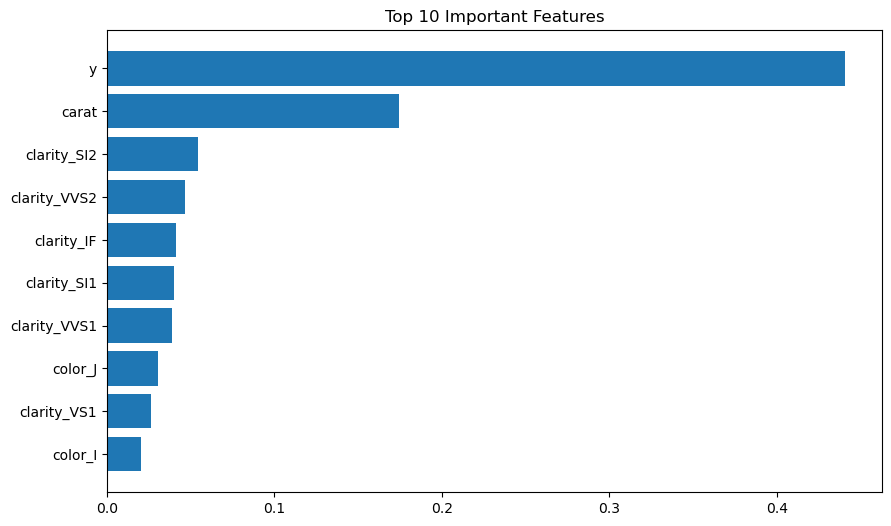

In [28]:
plt.figure(figsize=(10,6))
plt.barh(importance["Feature"][:10], importance["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()


In [29]:
print(importance.head(10))

         Feature  Importance
4              y    0.440637
0          carat    0.174235
18   clarity_SI2    0.054615
22  clarity_VVS2    0.046402
16    clarity_IF    0.041345
17   clarity_SI1    0.040237
21  clarity_VVS1    0.038714
15       color_J    0.030655
19   clarity_VS1    0.026291
14       color_I    0.020664


### Actual vs Predicted Sales

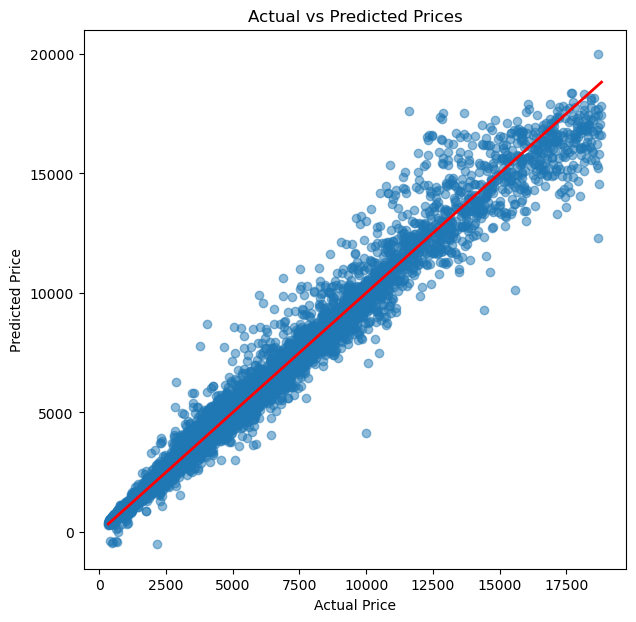

In [30]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

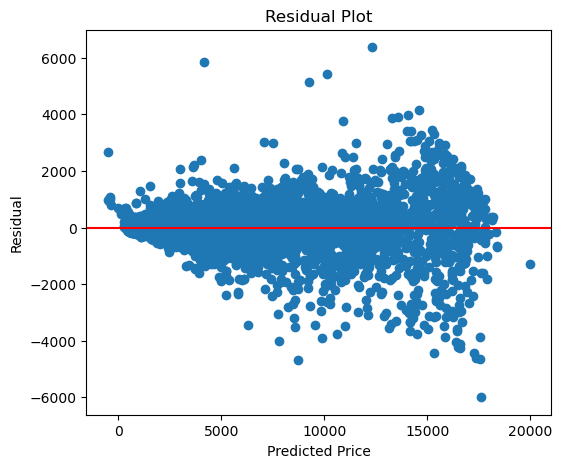

In [31]:
residual = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residual)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

### Model Comparison

In [32]:
import pandas as pd

result = pd.DataFrame({
    "Model":["Linear","Decision Tree","Random Forest","Gradient Boosting","KNN","XGBoost"],
    "R²":[0.859,0.778,0.880,0.886,0.868,0.887]
})

result.sort_values("R²",ascending=False)

,Model,R²
5,XGBoost,0.887
3,Gradient Boosting,0.886
2,Random Forest,0.880
4,KNN,0.868
0,Linear,0.859
1,Decision Tree,0.778


In [33]:
tuning_result = pd.DataFrame({"Model" :["XGBoost"], "Before GridSearchCV" : [0.887] , "After GridSearchCV" : [0.980]})
tuning_result

,Model,Before GridSearchCV,After GridSearchCV
0,XGBoost,0.887,0.98


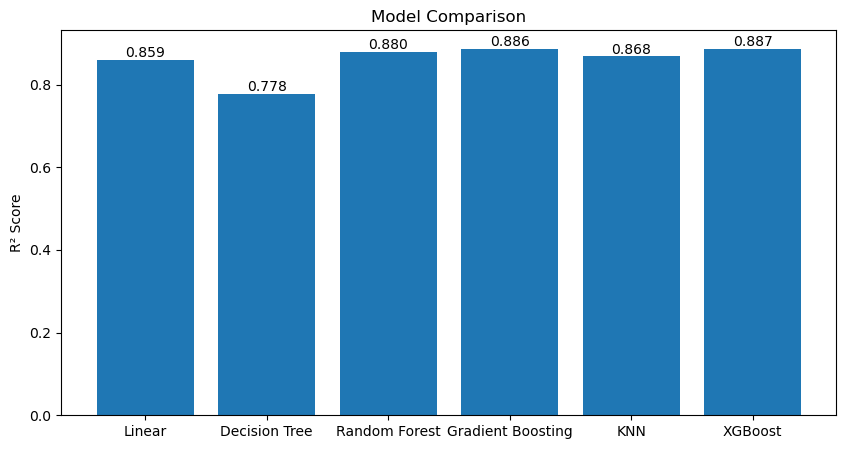

In [34]:
plt.figure(figsize=(10,5))
bars = plt.bar(result["Model"],result["R²"])
plt.bar_label(bars, fmt= "%.3f")
plt.title("Model Comparison")
plt.ylabel("R² Score")
plt.show()

### Save Trained Model

In [35]:
joblib.dump(best_model, "diamond_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## Conclusion